<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/supervised/classification/experiment_xgboost_classification_hyperparameter_tuning_progression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost

In [ ]:
# ============================================
# LEVEL 1: BASIC XGBOOST
# ============================================

import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# -------------------------------
# 1. Data
# -------------------------------
X = np.random.randn(1000, 2)
y = (X[:, 0] * X[:, 1] > 0).astype(int)

# -------------------------------
# 2. Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 3. Model
# -------------------------------
model_xgb1 = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

model_xgb1.fit(X_train, y_train)

preds = model_xgb1.predict(X_test)

accuracy_xgb1 = accuracy_score(y_test, preds)

print("Level 1 Accuracy:", accuracy_xgb1)

Level 1 Accuracy: 0.995


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:02:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# ============================================
# LEVEL 2: CONTROL LEARNING
# ============================================

model_xgb2 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric='logloss'
)

model_xgb2.fit(X_train, y_train)

preds2 = model_xgb2.predict(X_test)

accuracy_xgb2 = accuracy_score(y_test, preds2)

print("Level 2 Accuracy:", accuracy_xgb2)

Level 2 Accuracy: 0.995


In [ ]:
from sklearn.datasets import load_iris

data = load_iris()

X = data.data
y = data.target

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_xgb3 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric='mlogloss'
)

model_xgb3.fit(X_train3, y_train3)

preds3 = model_xgb3.predict(X_test3)

accuracy_xgb3 = accuracy_score(y_test3, preds3)

print("Level 3 Accuracy:", accuracy_xgb3)

Level 3 Accuracy: 1.0


In [ ]:
# ============================================
# LEVEL 4: TUNED XGBOOST
# ============================================

model_xgb4 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss'
)

model_xgb4.fit(X_train3, y_train3)

preds4 = model_xgb4.predict(X_test3)

accuracy_xgb4 = accuracy_score(y_test3, preds4)

print("Level 4 Accuracy:", accuracy_xgb4)

Level 4 Accuracy: 1.0


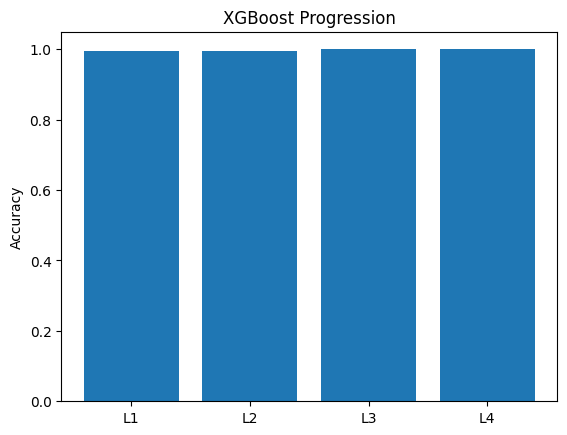

In [ ]:
levels = ["L1", "L2", "L3", "L4"]
accuracies = [accuracy_xgb1, accuracy_xgb2, accuracy_xgb3, accuracy_xgb4]

import matplotlib.pyplot as plt

plt.figure()
plt.bar(levels, accuracies)
plt.title("XGBoost Progression")
plt.ylabel("Accuracy")
plt.show()

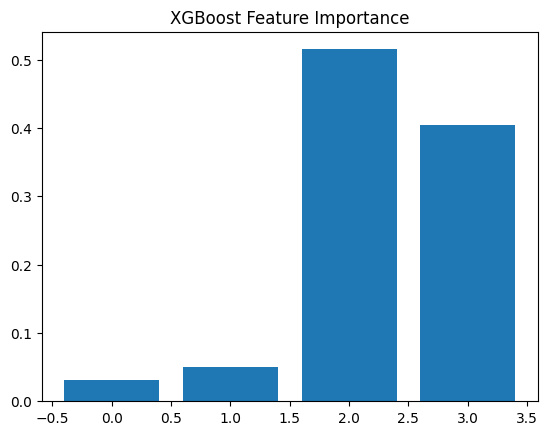

In [ ]:
import matplotlib.pyplot as plt

importance = model_xgb4.feature_importances_

plt.bar(range(len(importance)), importance)
plt.title("XGBoost Feature Importance")
plt.show()